# Graph Neural Network Modeling

This notebook builds a tract-level spatial graph and trains a GraphSAGE model to predict urban opportunity scores.

It includes:
- Spatial graph construction from tract adjacency
- Node feature preparation
- Graph neural network training
- Model evaluation
- Spatial prediction visualization

Output:
- PyTorch Geometric graph dataset
- Trained GraphSAGE model
- Spatial prediction maps and metrics

## Config

In [1]:
NAME = "New York City"
 
STATE = "36" # New York State

COUNTIES = [
    "005",  # Bronx
    "047",  # Brooklyn
    "061",  # Manhattan
    "081",  # Queens
    "085"   # Staten Island
]

TARGET_VARIABLE = "urban_opportunity_index"

## Imports

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

/home/beau/miniconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [3]:
NAME_FILE = NAME.strip().lower().replace(" ", "_")
nodes = pd.read_parquet(f"../data/{NAME_FILE}_tract_dataset.parquet")

nodes["GEOID"] = nodes["GEOID"].astype(str)

print(nodes.head(2))

         GEOID  total_population  median_income  population_density  \
0  36081003400              2559        79728.0         6869.633349   
1  36081003900              1436        53468.0         5599.661929   

   pct_under_18  pct_over_65  pct_bachelors_degree  employment_rate  \
0      0.178585     0.117233              0.262774         0.869735   
1      0.157382     0.072423              0.327256         0.989781   

   poverty_rate  road_density  intersection_density  transit_stop_density  \
0      0.160126     35.570357             64.427980             21.475993   
1      0.227019     43.399214             31.195888             23.396916   

   urban_opportunity_index  
0                32.647350  
1                41.092165  


## Load Census Tracts

In [4]:
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)

tracts = tracts.to_crs(epsg=4326)

tracts = tracts[
    tracts["COUNTYFP"].isin(COUNTIES)
].copy()

tracts["GEOID"] = tracts["GEOID"].astype(str)

## Merge

In [5]:
gdf = tracts.merge(
    nodes,
    on="GEOID",
    how="inner"
)

gdf = gpd.GeoDataFrame(
    gdf,
    geometry="geometry"
)

## Build Graph

In [6]:
def build_adjacency_edges(gdf):

    gdf = gdf.copy()

    gdf = gdf[gdf.geometry.notnull()]
    gdf = gdf[gdf.is_valid]

    sindex = gdf.sindex

    edges = []

    for idx, geom in gdf.geometry.items():

        possible = list(
            sindex.intersection(geom.bounds)
        )

        candidates = gdf.iloc[possible]

        neighbors = candidates[
            candidates.geometry.touches(geom)
        ]

        for n_idx in neighbors.index:
            edges.append((idx, n_idx))

    return edges

In [7]:
edges = build_adjacency_edges(gdf)

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 14886])


## Prepare Node Features

In [8]:
def prepare_node_features(gdf):

    exclude = ["GEOID"]

    feature_cols = gdf.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    feature_cols = [
        c for c in feature_cols
        if c not in exclude
    ]

    X = gdf[feature_cols].fillna(0).values

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    X = torch.tensor(
        X,
        dtype=torch.float
    )

    return X, feature_cols

In [9]:
X, feature_cols = prepare_node_features(gdf)

## Create Graph Dataset

In [10]:
data = Data(
    x=X,
    edge_index=edge_index
)

print(data)

Data(x=[2327, 14], edge_index=[2, 14886])


## Add Targets

In [11]:
y = torch.tensor(
    gdf[TARGET_VARIABLE].values,
    dtype=torch.float
)

data.y = y

## Train Test Split

In [12]:
num_nodes = gdf.shape[0]

idx = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42
)

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

## Define Model

In [13]:
class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels=64
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.lin = torch.nn.Linear(
            hidden_channels,
            1
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return self.lin(x).squeeze()

In [14]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = GraphSAGE(
    in_channels=data.x.shape[1]
).to(device)

data = data.to(device)

## Training Functions

In [15]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

loss_fn = torch.nn.MSELoss()

In [16]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(
        data.x,
        data.edge_index
    )

    loss = loss_fn(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [17]:
def evaluate():

    model.eval()

    out = model(
        data.x,
        data.edge_index
    )

    pred = out[data.test_mask]
    true = data.y[data.test_mask]

    rmse = torch.sqrt(
        loss_fn(pred, true)
    ).item()

    ss_res = ((pred - true) ** 2).sum()

    ss_tot = (
        (true - true.mean()) ** 2
    ).sum()

    r2 = (
        1 - ss_res / ss_tot
    ).item()

    return rmse, r2

## Train Model

In [18]:
for epoch in range(1, 201):

    loss = train()

    if epoch % 20 == 0:

        rmse, r2 = evaluate()

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"RMSE {rmse:.4f} | "
            f"R2 {r2:.4f}"
        )

Epoch 020 | Loss 186.4537 | RMSE 14.2450 | R2 0.2725
Epoch 040 | Loss 65.8401 | RMSE 7.8113 | R2 0.7813
Epoch 060 | Loss 29.0214 | RMSE 5.0821 | R2 0.9074
Epoch 080 | Loss 16.0672 | RMSE 3.9770 | R2 0.9433
Epoch 100 | Loss 10.7391 | RMSE 3.3335 | R2 0.9602
Epoch 120 | Loss 8.2357 | RMSE 2.9923 | R2 0.9679
Epoch 140 | Loss 6.6430 | RMSE 2.7368 | R2 0.9731
Epoch 160 | Loss 5.3677 | RMSE 2.5065 | R2 0.9775
Epoch 180 | Loss 4.3054 | RMSE 2.2884 | R2 0.9812
Epoch 200 | Loss 3.4483 | RMSE 2.1013 | R2 0.9842


## Generate Predictions

In [19]:
model.eval()

with torch.no_grad():

    pred = model(
        data.x,
        data.edge_index
    ).cpu().numpy()

gdf["prediction"] = pred

## Compute Metrics

In [20]:
y_true = data.y.cpu().numpy()

rmse = np.sqrt(
    mean_squared_error(
        y_true[data.test_mask.cpu()],
        pred[data.test_mask.cpu()]
    )
)

r2 = r2_score(
    y_true[data.test_mask.cpu()],
    pred[data.test_mask.cpu()]
)

print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

RMSE: 2.1013
R²: 0.9842


## Results

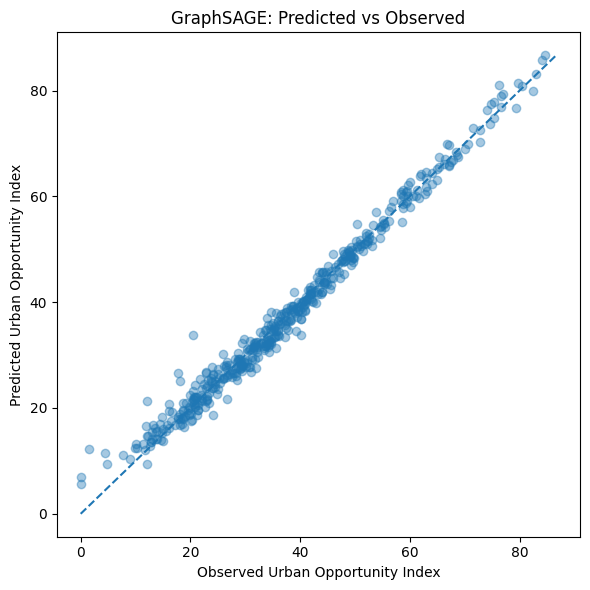

In [21]:
fig, ax = plt.subplots(
    figsize=(6, 6)
)

y_test = y_true[
    data.test_mask.cpu()
]

pred_test = pred[
    data.test_mask.cpu()
]

ax.scatter(
    y_test,
    pred_test,
    alpha=0.4
)

min_val = min(
    y_test.min(),
    pred_test.min()
)

max_val = max(
    y_test.max(),
    pred_test.max()
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

ax.set_xlabel(
    "Observed Urban Opportunity Index"
)

ax.set_ylabel(
    "Predicted Urban Opportunity Index"
)

ax.set_title(
    "GraphSAGE: Predicted vs Observed"
)

plt.tight_layout()
plt.show()

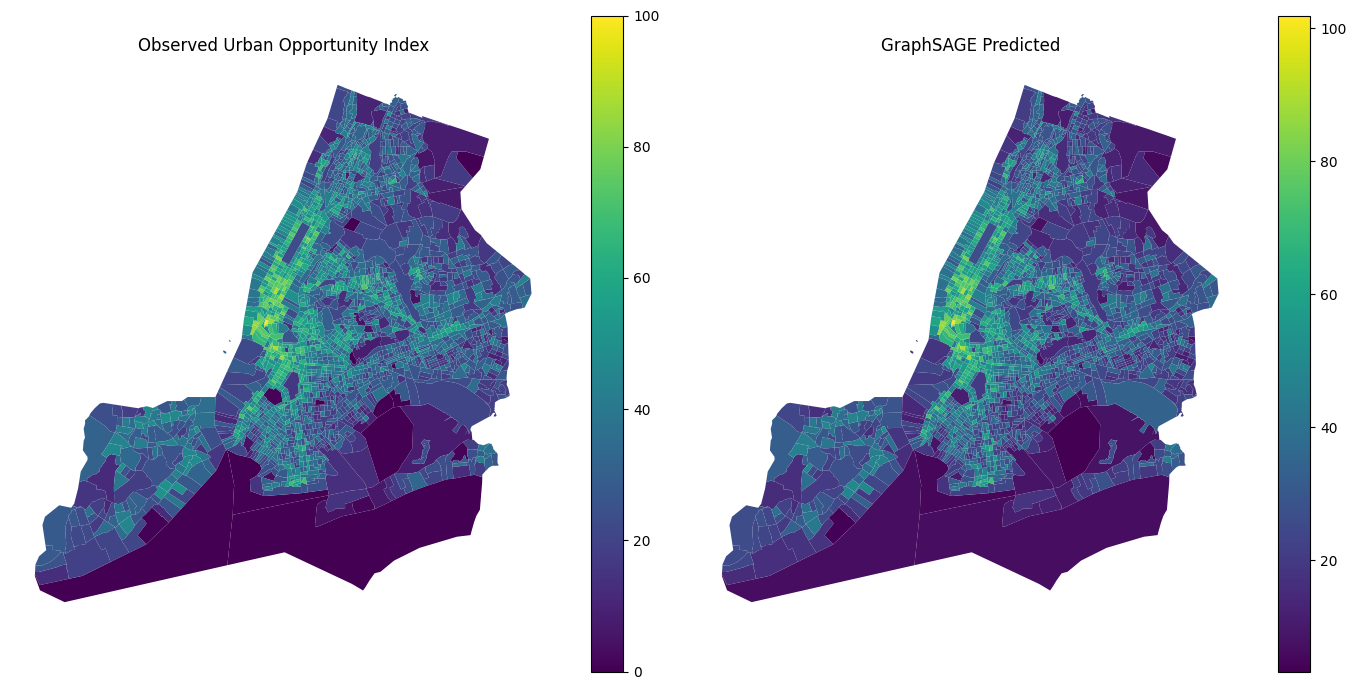

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

gdf.plot(
    column=TARGET_VARIABLE,
    cmap="viridis",
    legend=True,
    ax=axes[0]
)

axes[0].set_title(
    "Observed Urban Opportunity Index"
)

axes[0].axis("off")

gdf.plot(
    column="prediction",
    cmap="viridis",
    legend=True,
    ax=axes[1]
)

axes[1].set_title(
    "GraphSAGE Predicted"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()